# Understanding COE price dynamics in a constrained auction market.

### Introduction

This study examines whether COE premiums in Singapore behave in line with
traditional supply–demand dynamics, with particular focus on the role of
supply-side mechanisms under a regulated quota system.

While the total Category A vehicle population has remained broadly stable
since 2016, COE premiums have continued to exhibit large cyclical swings.
This apparent decoupling motivates a deeper investigation into *flow-based*
supply variables—namely deregistrations, quota allocations, new registrations,
and bidding activity—rather than stock-level population measures.

---


### Data & Methodology

### Data Sources

This analysis uses publicly available administrative data from Data.gov.sg, including:

- Monthly COE auction data (quota, bids received, quota premium) by category and bidding round  
- Vehicle deregistration data, which feeds into future COE quota supply  
- New vehicle registrations as a proxy for demand  
- Vehicle population under the VQS to capture longer-term stock constraints  

All datasets were pulled via API to keep the workflow reproducible.

### Data Preparation

The raw datasets are not analysis-ready. Most variables are embedded in text labels, and months are stored as columns. To clean the data:

- All datasets were reshaped into long, monthly time-series format  
- Month strings were converted into proper datetime values  
- COE categories and bidding rounds were extracted from text fields  
- Quota, bids, premiums, deregistrations, registrations, and population were separated into distinct numeric columns  
- Data was aggregated consistently at the monthly category level and aligned across datasets  

This resulted in a single, structured dataset linking auction outcomes with supply, demand, and vehicle stock dynamics.

---


In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
from scipy.stats import spearmanr, ttest_1samp
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

#Motor Vehicle Quota, Quota Premium And Prevailing Quota Premium, Monthly - Feb 2002 to Dec 2024
dataset_id = "d_22094bf608253d36c0c63b52d852dd6e"

#Annual Revalidation of Certificate of Entitlement (COE) of Existing Vehicles - 2006 to 2017
annual_coe_reval = "d_71ce745d4e4ea9cd2fea0fdf46412fc8"

#Monthly Revalidation of COE - Data from Jan 2015 to Jan 2018
monthly_coe_reval = "d_11af4cacfdd459f8712fb903b1639d98"

#Motor Vehicle Population Under Vehicle Quota System, (As At End Of Period), Monthly - May 1990 to Nov 2024
veh_pop = "d_ede1a559013d10f234d209ac5e9fd9b4"

#Motor Vehicles De-Registered Under Vehicle Quota System, Monthly - May 1990 to Nov 2024
veh_dereg = "d_d520d6034b5e0c4f883b4e480de28f97"

#New Registration Of Motor Vehicles Under Vehicle Quota System , Monthly - May 1990 to Nov 2024
veh_reg = "d_529752a3d78beb78bd4f38e3be37f1b6"


In [5]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + dataset_id

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)

results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')

results_df['bidding'] = results_df['DataSeries'].apply(
    lambda x: 1 if "1st Bidding" in x else (
        2 if '2nd Bidding' in x else 0
        )
    )

results_df['coe_category'] = results_df['DataSeries'].apply(
    lambda x: 'A' if 'Cars Up To 1600cc' in x else (
        'B' if 'Cars Above 1600cc' in x else (
            'C' if 'Goods Vehicles & Buses' in x else (
                'D' if 'Motorcycles' in x else (
                    'E' if 'Open Category' in x else None
                )
            )
        )
        
    )
)

results_df['quota'] = np.nan
results_df['bids_received'] = np.nan
results_df['successful_bids'] = np.nan
results_df['quota_premium'] = np.nan

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota', case=False)) & 
    (~results_df['DataSeries'].str.contains('Premium', case=False)),
    'quota'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Bids Received', case=False)),
    'bids_received'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Successful Bids', case=False)),
    'successful_bids'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota Premium', case=False)) &
    (~results_df['DataSeries'].str.contains('Prevailing', case=False)),
    'quota_premium'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Prevailing Quota Premium', case=False)),
    'prevailing_quota_premium'
] = results_df['value']

results_df.dropna(subset=['coe_category'], inplace=True)

agg_df = results_df.pivot_table(
    index = ['month', 'bidding', 'coe_category'],
    values=['quota', 'bids_received', 'successful_bids', 'quota_premium', 'prevailing_quota_premium'],
    aggfunc='first'
).reset_index()

agg_df.set_index(['month', 'bidding', 'coe_category'], inplace=True)
agg_df.sort_values(['month', 'bidding', 'coe_category'], inplace=True)

coe_df = agg_df.copy()

In [7]:
print(coe_df.tail())

                                 bids_received  prevailing_quota_premium  \
month      bidding coe_category                                            
2026-02-01 2       A                    1975.0                  106541.0   
                   B                    1353.0                  115938.0   
                   C                     502.0                   75669.0   
                   D                     665.0                    8367.0   
                   E                     571.0                       NaN   

                                  quota  quota_premium  successful_bids  
month      bidding coe_category                                          
2026-02-01 2       A             1289.0       106501.0           1289.0  
                   B              813.0       105001.0            812.0  
                   C              294.0        74999.0            294.0  
                   D              548.0         7989.0            535.0  
                   E   

In [11]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_dereg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'dereg_a': 'Category A',
    'dereg_b': 'Category B',
    'dereg_c': 'Category C',
    'dereg_offpeak': 'Weekend Cars/Off Peak Cars',
    'dereg_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['dereg_a', 'dereg_b', 'dereg_c', 'dereg_offpeak', 'dereg_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_dereg_df = agg_df.copy()

In [12]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_reg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'new_a': 'Category A',
    'new_b': 'Category B',
    'new_c': 'Category C',
    'new_offpeak': 'Weekend Cars/Off Peak Cars',
    'new_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['new_a', 'new_b', 'new_c', 'new_offpeak', 'new_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_new_df = agg_df.copy()

In [13]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_pop

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'pop_a': 'Category A',
    'pop_b': 'Category B',
    'pop_c': 'Category C',
    'pop_offpeak': 'Weekend Cars/Off Peak Cars',
    'pop_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['pop_a', 'pop_b', 'pop_c', 'pop_offpeak', 'pop_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_pop_df = agg_df.copy()

In [18]:
print(veh_pop_df)

               pop_a     pop_b     pop_c  pop_offpeak  pop_total
month                                                           
1990-05-01  219348.0   49128.0  118289.0          0.0   532305.0
1990-06-01  219746.0   49431.0  118505.0          0.0   533676.0
1990-07-01  219774.0   49640.0  118478.0          0.0   534210.0
1990-08-01  220101.0   49999.0  118941.0          0.0   535747.0
1990-09-01  220462.0   50309.0  119345.0          0.0   537274.0
...              ...       ...       ...          ...        ...
2025-07-01  322639.0  336272.0  153046.0          0.0  1010286.0
2025-08-01  322505.0  336121.0  152841.0          0.0  1010085.0
2025-09-01  322084.0  336292.0  152649.0          0.0  1010363.0
2025-10-01  321522.0  336111.0  152555.0          0.0  1009811.0
2025-11-01  321636.0  336172.0  152572.0          0.0  1010370.0

[427 rows x 5 columns]


In [14]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + monthly_coe_reval

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

category_map = {
    "Category A": "cat_a",
    "Category B": "cat_b",
    "Category C": "cat_c",
    "Category D": "cat_d"
}

df['number'] = pd.to_numeric(df['number'], errors='coerce')
df["category"] = df["category"].map(category_map)
df['month'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')

agg_df = df.pivot_table(
    index=['month', 'type'],
    columns='category',
    values='number',
    aggfunc='mean'
)

agg_df.columns.name = None
monthly_coe_reval_df = agg_df.copy()


In [15]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + annual_coe_reval

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

category_map = {
    "Category A": "cat_a",
    "Category B": "cat_b",
    "Category C": "cat_c",
    "Category D": "cat_d"
}

df['number'] = pd.to_numeric(df['number'], errors='coerce')
df["category"] = df["category"].map(category_map)
df['year'] = pd.to_datetime(df['year'], format='%Y', errors='coerce')

agg_df = df.pivot_table(
    index=['year', 'type'],
    columns='category',
    values='number',
    aggfunc='mean'
)

agg_df.columns.name = None
yearly_coe_reval_df = agg_df.copy()

Cat A data aggregation and cleaning

In [16]:
cat_a = coe_df.xs(key='A', level='coe_category')
cat_a_df = cat_a.groupby('month').agg({
    'quota': 'sum',
    'bids_received': 'sum',
    'successful_bids': 'sum',
    'quota_premium': 'mean',
    'prevailing_quota_premium': 'mean'
}).add_suffix('_a')

veh_dereg_cat_a = veh_dereg_df[['dereg_a']]
veh_new_cat_a = veh_new_df[['new_a']]
veh_pop_cat_a = veh_pop_df[['pop_a']]

cat_a_df = cat_a_df.merge(veh_dereg_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_new_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_pop_cat_a, left_index=True, right_index=True, how='left')

coe_monthly_a = monthly_coe_reval_df[['cat_a']].reset_index().pivot(index='month', columns='type', values='cat_a')
coe_monthly_a.columns.name = None

coe_yearly_a = yearly_coe_reval_df[['cat_a']].reset_index().pivot(index='year', columns='type', values='cat_a')
coe_yearly_a.columns.name = None

columns = ['quota_a', 'bids_received_a', 'successful_bids_a']
cat_a_df[columns] = cat_a_df[columns].replace(0, np.nan)

print(cat_a_df.head())
print(coe_monthly_a.head())
print(coe_yearly_a.head())


            quota_a  bids_received_a  successful_bids_a  quota_premium_a  \
month                                                                      
2002-02-01   2940.0           7284.0             2916.0          30000.0   
2002-03-01   2959.0           7067.0             2920.0          32342.5   
2002-04-01   2259.0           4374.0             2240.0          36600.5   
2002-05-01   2239.0           3025.0             2207.0          34200.5   
2002-06-01   2252.0           2764.0             2238.0          31645.0   

            prevailing_quota_premium_a  dereg_a   new_a     pop_a  
month                                                              
2002-02-01                     29446.0   2998.0  2182.0  275044.0  
2002-03-01                     30559.0   5038.0  4030.0  274036.0  
2002-04-01                     32981.0   3883.0  3275.0  273428.0  
2002-05-01                     34382.0   3103.0  2725.0  273050.0  
2002-06-01                     34149.0   3039.0  2798.0  27

## Exploratory Data Analysis

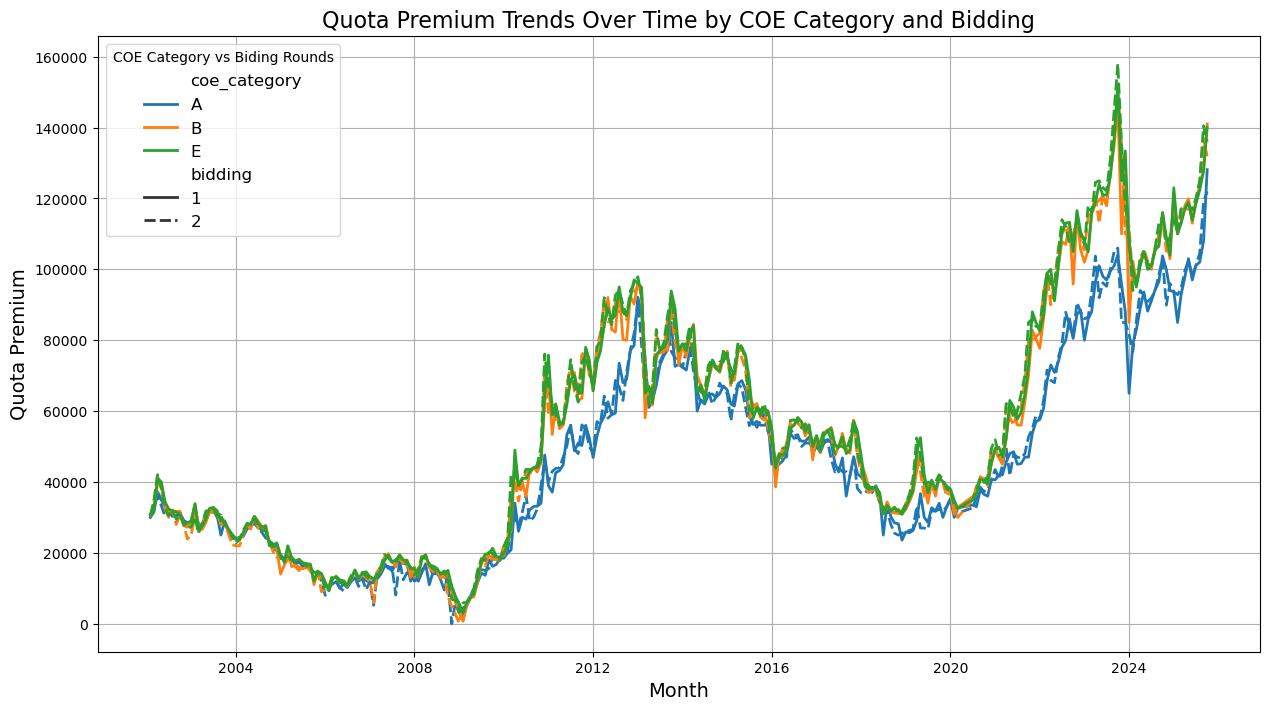

In [20]:
coe_df = coe_df[~coe_df.index.get_level_values('coe_category').isin(['C', 'D'])]

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=coe_df,
    x='month',
    y='quota_premium',
    hue='coe_category',
    style='bidding',
    markers=False,
    dashes=True,
    linewidth=2
)
plt.title("Quota Premium Trends Over Time by COE Category and Bidding", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Quota Premium", fontsize=14)
plt.legend(title="COE Category vs Biding Rounds", fontsize=12)
plt.grid(True)
plt.show()


Focus narrow to Cat A prices since Cat A represents entry level COE prices and premiums across all categories co-move together strongly.

In [30]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.colors as pc

#Net flow df
cat_a_df['net_flow_a'] = cat_a_df['dereg_a'] - cat_a_df['new_a']

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[1, 1, 1],
    subplot_titles=(
        "Category A Population vs Quota Premium",
        "Category A New Registrations vs Deregistrations",
        "Category A Net Supply Flow vs Quota Premium"
    ),
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{"secondary_y": True}]
    ]
)

# Row 1: Population vs Premium
fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['pop_a'],
        mode='lines',
        name='Population (Cat A)',
        line=dict(color=pc.qualitative.Plotly[0])
    ),
    row=1, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_premium_a'],
        mode='lines',
        name='Quota Premium',
        line=dict(color=pc.qualitative.Plotly[1])
    ),
    row=1, col=1, secondary_y=True
)


# Row 2: New Registrations vs Dereg
fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['new_a'],
        mode='lines',
        name='New Registrations',
        line=dict(color=pc.qualitative.Plotly[2])
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['dereg_a'],
        mode='lines',
        name='Deregistrations',
        line=dict(color=pc.qualitative.Plotly[3])
    ),
    row=2, col=1
)


# Row 3: Net Flow vs Premium
fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['net_flow_a'],
        mode='lines',
        name='Net Flow (Dereg − New)',
        line=dict(color=pc.qualitative.Plotly[4])
    ),
    row=3, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_premium_a'],
        mode='lines',
        name='Quota Premium',
        line=dict(color=pc.qualitative.Plotly[1]),
        showlegend=False
    ),
    row=3, col=1, secondary_y=True
)


fig.update_layout(
    height=1300,
    width=1000,
    title={
        'text': "Category A COE: Population, Supply Flows & Price Dynamics",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    template='plotly_dark',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(title_text="Month-Year")

fig.update_yaxes(title_text="Vehicle Population", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="Number of Vehicles", row=2, col=1)

fig.update_yaxes(title_text="Net Flow", row=3, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=3, col=1, secondary_y=True)

fig.show()


Visual inspection shows Category A vehicle population stabilising around
320,000 units from 2016 onwards. This is corroborated statistically by a
one-sample t-test on post-2016 net supply flows (deregistrations minus new
registrations), which fails to reject the null hypothesis that the mean net
flow is zero.

Together, these results indicate that the post-2016 COE regime operates
around a stable population equilibrium, with no sustained net expansion
or contraction in Category A vehicle stock.

In [80]:
net_flow = cat_a_df['net_flow_a']

pre_2016 = net_flow.loc[:'2015-12-01']
post_2016 = net_flow.loc['2016-01-01':]
post_2016_clean = post_2016.dropna()

t_stat, p_val = ttest_1samp(post_2016_clean, 0)

print(t_stat)
print(p_val)

y = post_2016_clean.values
X = sm.add_constant(np.arange(len(y)))

trend_model = sm.OLS(y, X).fit()
trend_model.summary()

-0.09790300854800885
0.9221812395542068


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.998
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.160
Time:                        22:31:58   Log-Likelihood:                -903.89
No. Observations:                 115   AIC:                             1812.
Df Residuals:                     113   BIC:                             1817.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        137.3702    117.204      1.172      0.244     -94.832     369.572
x1            -2.5118      1.777     -1.414      0.160      -6.032       1.008
==============================================================================
Omnibus:                        6.918   Durbin-Watson:                   1.328
Prob(Omnibus):                  0.031   Jarque-Bera (JB):               11.754
Skew:                           0.121   Prob(JB):                      0.00280
Kurtosis:                       4.547   Cond. No.                         131.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.colors as pc


fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.10,
    subplot_titles=(
        "Deregistered Vehicles vs Quota (Cat A)",
        "Quota vs Quota Premium (Cat A)",
        "Deregistered Vehicles vs Quota Premium (Cat A)"
    ),
    specs=[
        [{"secondary_y": True}],
        [{"secondary_y": True}],
        [{"secondary_y": True}],
    ]
)


fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["dereg_a"],
        mode="lines", name="Deregistered Vehicles",
        line=dict(color=pc.qualitative.Plotly[1])
    ),
    row=1, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["quota_a"],
        mode="lines", name="Quota",
        line=dict(color=pc.qualitative.Plotly[0])
    ),
    row=1, col=1, secondary_y=True
)


fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["quota_a"],
        mode="lines", name="Quota (repeat)",
        line=dict(color=pc.qualitative.Plotly[0]),
        showlegend=False
    ),
    row=2, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["quota_premium_a"],
        mode="lines", name="Quota Premium",
        line=dict(color=pc.qualitative.Plotly[2])
    ),
    row=2, col=1, secondary_y=True
)


fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["dereg_a"],
        mode="lines", name="Deregistered Vehicles (repeat)",
        line=dict(color=pc.qualitative.Plotly[1]),
        showlegend=False
    ),
    row=3, col=1, secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=cat_a_df.index, y=cat_a_df["quota_premium_a"],
        mode="lines", name="Quota Premium (repeat)",
        line=dict(color=pc.qualitative.Plotly[2]),
        showlegend=False
    ),
    row=3, col=1, secondary_y=True
)


fig.update_layout(
    height=1100,
    width=1000,
    template="plotly_dark",
    title=dict(
        text="Category A COE: Deregistration, Quota, and Premium Dynamics",
        x=0.5, xanchor="center"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.18,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(title_text="Month-Year", row=3, col=1)

fig.update_yaxes(title_text="Deregistered Vehicles", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota", row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="Quota", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=2, col=1, secondary_y=True)

fig.update_yaxes(title_text="Deregistered Vehicles", row=3, col=1, secondary_y=False)
fig.update_yaxes(title_text="Quota Premium (SGD)", row=3, col=1, secondary_y=True)

fig.show()


first image: reg vs dereg shows strong positive rs, dereg precedes reg 

population cap, stabilizing at 320k post 2016, while price still shows swing, decoupling of price from population cap. further evidence of net supply oscilating 0 post 2016. 
no sustained net negative supply growth/declining population but with increasing premiums post 2016 shows supply is not the main driver, points towards other forces and externalities, eg post covid demand normalization, increasing household income, or increase dominance of fleet, rental (expansion of PHV) data strongly suggest economical drivers affecting demand at work. 

second image: positive rs of dereg vs quota, dereg precedes quota, meaning quota is directly related to deregistered vehicles. consider exploring deeper rs between deregistered vehicles vs quota vs quota premiums. 

quota vs quota premiums, and dereg vs quota premiums, clear inverse rs.

Next: spearman corr to identify relationships worthy of further investigation

In [43]:
corr_df = cat_a_df[[
    'quota_a',
    'bids_received_a',
    'quota_premium_a',
    'dereg_a',
    'new_a'
]].copy()

corr_df.loc['2024-12-01', 'dereg_a'] = 1973
corr_df['net_supply_a'] = corr_df['dereg_a'] - corr_df['new_a']

corr_df.interpolate(method='time', inplace=True)
corr_df = corr_df.round(1)

corr_df.dropna(inplace=True)

def spearman_corr_pval(df):
    cols = df.columns
    corr = pd.DataFrame(index=cols, columns=cols, dtype=float)
    pval = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for i in cols:
        for j in cols:
            r, p = spearmanr(df[i], df[j])
            corr.loc[i, j] = r
            pval.loc[i, j] = p

    return corr, pval

corr_lvl, pval_lvl = spearman_corr_pval(corr_df)

print("Spearman Correlation (Levels)")
print(corr_lvl.round(3))

print("\nP-values")
print(pval_lvl.round(4))


Spearman Correlation (Levels)
                 quota_a  bids_received_a  quota_premium_a  dereg_a  new_a  \
quota_a            1.000            0.948           -0.706    0.855  0.941   
bids_received_a    0.948            1.000           -0.632    0.854  0.875   
quota_premium_a   -0.706           -0.632            1.000   -0.534 -0.697   
dereg_a            0.855            0.854           -0.534    1.000  0.873   
new_a              0.941            0.875           -0.697    0.873  1.000   
net_supply_a      -0.326           -0.199            0.431    0.068 -0.393   

                 net_supply_a  
quota_a                -0.326  
bids_received_a        -0.199  
quota_premium_a         0.431  
dereg_a                 0.068  
new_a                  -0.393  
net_supply_a            1.000  

P-values
                 quota_a  bids_received_a  quota_premium_a  dereg_a  new_a  \
quota_a              0.0           0.0000              0.0   0.0000    0.0   
bids_received_a      0.0         

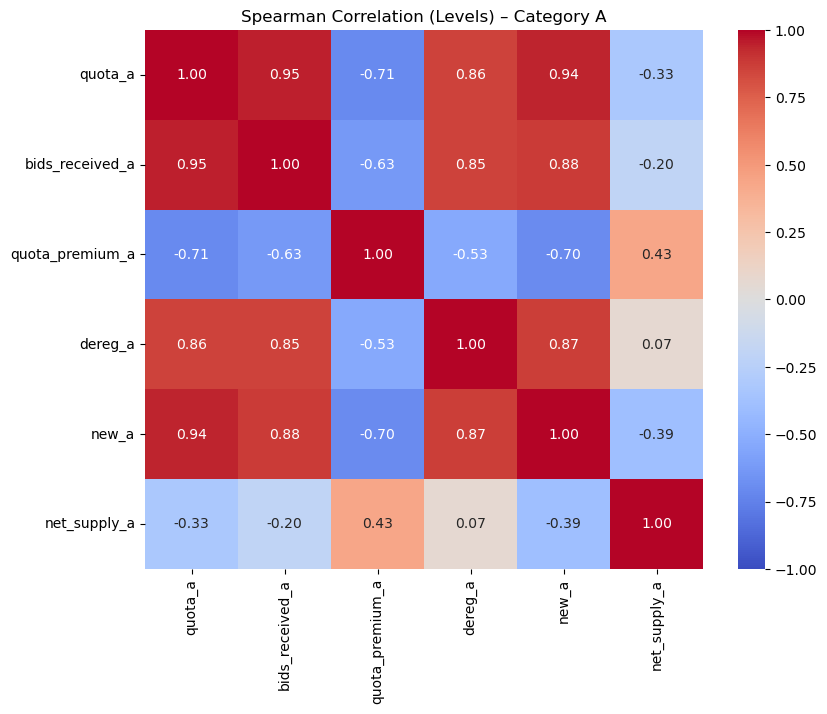

In [44]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_lvl,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Spearman Correlation (Levels) – Category A")
plt.show()


In [45]:
#Spearman corr on first differences

corr_diff_df = corr_df.diff().dropna()

corr_diff, pval_diff = spearman_corr_pval(corr_diff_df)

print("Spearman Correlation (First Differences)")
print(corr_diff.round(3))


Spearman Correlation (First Differences)
                 quota_a  bids_received_a  quota_premium_a  dereg_a  new_a  \
quota_a            1.000            0.417           -0.042    0.072  0.088   
bids_received_a    0.417            1.000            0.125    0.153  0.104   
quota_premium_a   -0.042            0.125            1.000    0.040 -0.002   
dereg_a            0.072            0.153            0.040    1.000  0.515   
new_a              0.088            0.104           -0.002    0.515  1.000   
net_supply_a      -0.069            0.033            0.057    0.176 -0.644   

                 net_supply_a  
quota_a                -0.069  
bids_received_a         0.033  
quota_premium_a         0.057  
dereg_a                 0.176  
new_a                  -0.644  
net_supply_a            1.000  


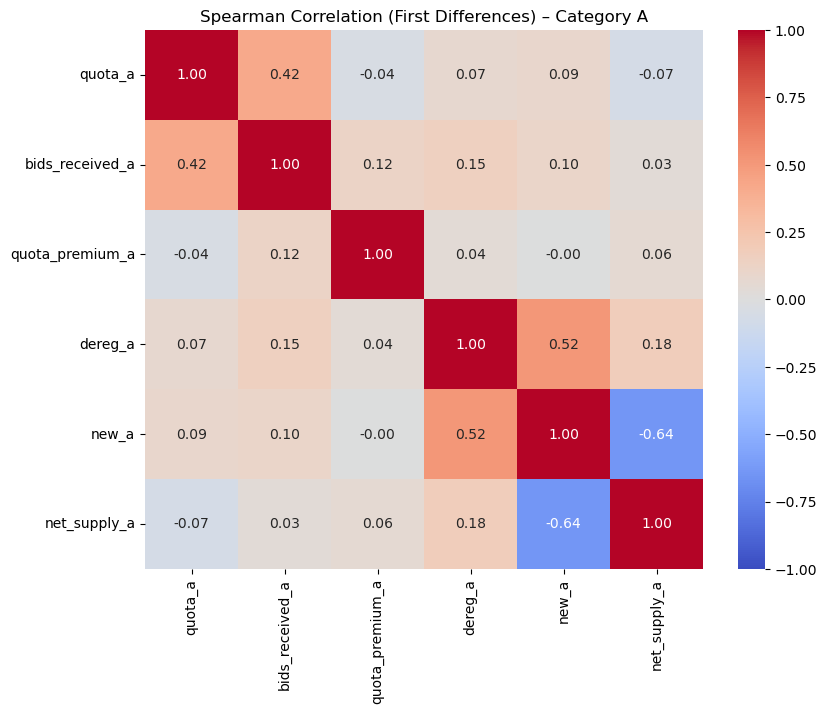

In [46]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_diff,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Spearman Correlation (First Differences) – Category A")
plt.show()


In [67]:
def lagged_spearman(x, y, max_lag=12):
    results = []
    for lag in range(1, max_lag + 1):
        r, p = spearmanr(x.shift(lag).iloc[lag:], y.iloc[lag:])
        results.append({
            'lag_months': lag,
            'spearman_corr': r,
            'p_value': p
        })
    return pd.DataFrame(results)

lag_dereg_quota = lagged_spearman(
    corr_df['dereg_a'],
    corr_df['quota_a']
)

lag_dereg_premium = lagged_spearman(
    corr_df['dereg_a'],
    corr_df['quota_premium_a']
)

print("Lagged Dereg → Quota")
print(lag_dereg_quota)

print("\nLagged Dereg → Premium")
print(lag_dereg_premium)


Lagged Dereg → Quota
    lag_months  spearman_corr        p_value
0            1       0.865371   1.334394e-86
1            2       0.881276   1.840182e-93
2            3       0.893101   3.864419e-99
3            4       0.903968  6.048947e-105
4            5       0.906870  2.454069e-106
5            6       0.909119  2.318670e-107
6            7       0.913756  5.634478e-110
7            8       0.910846  1.083959e-107
8            9       0.907725  2.353068e-105
9           10       0.903016  3.598503e-102
10          11       0.898704   2.297566e-99
11          12       0.884819   7.146088e-92

Lagged Dereg → Premium
    lag_months  spearman_corr       p_value
0            1      -0.556278  1.797767e-24
1            2      -0.581866  4.870438e-27
2            3      -0.604194  1.894979e-29
3            4      -0.625044  7.352419e-32
4            5      -0.642766  4.951618e-34
5            6      -0.658653  4.400342e-36
6            7      -0.675420  2.193909e-38
7            8    

## Correlation Analysis: Findings and Interpretation

### Correlations in Levels (Structural Relationships)

Spearman correlations on the level data show strong and statistically significant associations across most variables:

- **Quota, bids received, new registrations, and deregistrations** are all highly positively correlated.
- **Quota premiums** exhibit a strong **negative correlation** with quota, deregistrations, new registrations, and bids received.

Correlation analysis at levels reveals strong positive associations among deregistrations, quota, bids received, and new registrations, reflecting the
institutional design of the COE system where vehicle turnover, quota supply,
and participation move together over the long run.

Quota premiums exhibit strong negative correlations with quota and
deregistrations, consistent with basic supply intuition. However, these
relationships primarily capture shared long-term cycles rather than
short-run price formation.


---

### Correlations in First Differences (Short-Run Dynamics)

When examining first differences to remove common trends:

- Most correlations involving **changes in quota premiums collapse toward zero**.
- Month-to-month changes in quota, deregistrations, and new registrations show **little contemporaneous association** with changes in premiums.
- The only moderate relationship that remains is between **changes in quota and changes in bids received**, suggesting bidding activity adjusts quickly to quota changes.

This
suggests that short-term price movements are not driven by immediate changes
in quota, deregistrations, or registrations, but instead reflect demand-side
adjustments, expectations, and auction dynamics.


---

### Lagged Correlations (Lead–Lag Structure)

Lagged Spearman correlations provide clearer insight into temporal relationships:

- **Deregistrations strongly lead quota**, with correlations increasing steadily across 1–6 month lags. This supports the institutional mechanism where quota allocations are based on historical deregistration volumes.
- **Deregistrations also lead quota premiums negatively**, indicating that increases in deregistration volume are followed by easing price pressure with a delay.
- The lagged relationship is substantially stronger than contemporaneous correlations, suggesting that supply effects transmit gradually rather than instantaneously.

These findings support a delayed transmission channel from **deregistration → quota → premium**, rather than a direct contemporaneous effect.



In [50]:
#Stationarity test for raw features

def adf_test(series, series_name):
    adf_summaries = []
    for columns in series.columns:
        adf_results = adfuller(series[columns])
        adf_summary = {
            'ADF Statistic': adf_results[0],
            'p-value': adf_results[1],
            '1%': adf_results[4]['1%'],
            '5%': adf_results[4]['5%'],
            '10%': adf_results[4]['10%'],
        }
        adf_summaries.append(adf_summary)
    adf_df = pd.DataFrame(adf_summaries, index=series.columns)
    print(f"ADF Test Results for {series_name}")
    print(adf_df)

diff_cat_a = corr_df.diff().dropna()

adf_test(corr_df, "Cat A Original")
adf_test(diff_cat_a, "Cat A Differenced")


ADF Test Results for Cat A Original
                 ADF Statistic   p-value        1%        5%       10%
quota_a              -2.669389  0.079487 -3.454622 -2.872225 -2.572464
bids_received_a      -1.734579  0.413390 -3.454713 -2.872265 -2.572485
quota_premium_a       0.748850  0.990764 -3.453838 -2.871881 -2.572280
dereg_a              -2.013699  0.280599 -3.454622 -2.872225 -2.572464
new_a                -2.451387  0.127755 -3.454988 -2.872386 -2.572549
net_supply_a         -3.542268  0.006966 -3.453754 -2.871844 -2.572261
ADF Test Results for Cat A Differenced
                 ADF Statistic       p-value        1%        5%       10%
quota_a              -2.623031  8.833007e-02 -3.454622 -2.872225 -2.572464
bids_received_a      -4.765512  6.327880e-05 -3.454713 -2.872265 -2.572485
quota_premium_a     -14.825784  1.932660e-27 -3.453670 -2.871808 -2.572241
dereg_a              -3.946598  1.717457e-03 -3.454622 -2.872225 -2.572464
new_a                -3.053531  3.018875e-02 -3.45508

ADF tests indicate that COE quota, demand, and premium series are non-stationary in levels but become stationary after first differencing, consistent with I(1) economic processes. Net supply, however, is stationary in levels, reflecting policy-driven mean reversion in vehicle stock. Subsequent analysis therefore focuses on differenced series to avoid spurious inference.

In [85]:
df = corr_df.copy()
df = df.asfreq('MS')

# --- Transformations ---
d_counts = df[['quota_a', 'bids_received_a', 'dereg_a', 'new_a', 'net_supply_a']].diff()
d_premium = np.log(df[['quota_premium_a']]).diff()

granger_df = pd.concat([d_counts, d_premium], axis=1).dropna()
granger_df.columns = [
    'd_quota', 'd_bids', 'd_dereg', 'd_new', 'd_net_supply', 'd_log_premium'
]

In [86]:
def granger_test_table(data: pd.DataFrame, y: str, x: str, max_lag: int = 12, verbose: bool = False):
    """
    Test whether x Granger-causes y using lags 1..max_lag.
    Returns a tidy dataframe with p-values for each lag (SSR F-test).
    """
    test_data = data[[y, x]].dropna()

    results = grangercausalitytests(test_data, maxlag=max_lag, verbose=verbose)

    rows = []
    for lag in range(1, max_lag + 1):
        ftest_p = results[lag][0]['ssr_ftest'][1]
        ftest_f = results[lag][0]['ssr_ftest'][0]
        chi2_p  = results[lag][0]['ssr_chi2test'][1]
        rows.append({
            "y": y,
            "x": x,
            "lag": lag,
            "ssr_F": ftest_f,
            "ssr_F_pvalue": ftest_p,
            "chi2_pvalue": chi2_p
        })

    out = pd.DataFrame(rows)
    out["reject_5pct"] = out["ssr_F_pvalue"] < 0.05
    return out


In [89]:
tests_to_run = [
    ("d_quota", "d_dereg"),
    ("d_log_premium", "d_dereg"),
    ("d_log_premium", "d_bids"),
    ("d_log_premium", "d_quota"),
    ("d_log_premium", "d_new"),
    ("d_quota", "d_new"),
    ('d_bids', 'd_dereg'),
    ('d_new', 'd_dereg'),
    ('d_bids', 'd_quota'),
    ('d_new', 'd_quota'),

]

all_results = []
for y, x in tests_to_run:
    res = granger_test_table(granger_df, y=y, x=x, max_lag=6, verbose=False)
    all_results.append(res)

granger_results = pd.concat(all_results, ignore_index=True)

granger_results.sort_values(["ssr_F_pvalue"]).head(15)

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since func

,y,x,lag,ssr_F,ssr_F_pvalue,chi2_pvalue,reject_5pct
58,d_new,d_quota,5,15.179798,3.926632e-13,1.349066e-15,True
59,d_new,d_quota,6,12.597437,1.692968e-12,5.001692e-15,True
53,d_bids,d_quota,6,7.091496,5.093461e-07,5.527260e-08,True
57,d_new,d_quota,4,8.862558,9.719023e-07,2.149299e-07,True
52,d_bids,d_quota,5,7.587667,1.101465e-06,1.887352e-07,True
50,d_bids,d_quota,3,9.935919,3.072241e-06,1.047413e-06,True
51,d_bids,d_quota,4,8.160037,3.161095e-06,8.488445e-07,True
56,d_new,d_quota,3,9.757492,3.882105e-06,1.366546e-06,True
49,d_bids,d_quota,2,9.640273,8.965278e-05,5.466511e-05,True
48,d_bids,d_quota,1,13.881811,2.354582e-04,1.798651e-04,True


In [90]:
summary = (
    granger_results
    .sort_values(["y", "x", "ssr_F_pvalue"])
    .groupby(["y", "x"], as_index=False)
    .first()[["y", "x", "lag", "ssr_F_pvalue", "reject_5pct"]]
    .sort_values("ssr_F_pvalue")
)

summary


,y,x,lag,ssr_F_pvalue,reject_5pct
7,d_new,d_quota,5,3.926632e-13,True
1,d_bids,d_quota,6,5.093461e-07,True
9,d_quota,d_new,1,2.567827e-04,True
8,d_quota,d_dereg,6,4.140289e-03,True
4,d_log_premium,d_new,2,1.634843e-02,True
2,d_log_premium,d_bids,6,2.000798e-02,True
5,d_log_premium,d_quota,6,1.181678e-01,False
0,d_bids,d_dereg,6,1.462186e-01,False
3,d_log_premium,d_dereg,2,1.634511e-01,False
6,d_new,d_dereg,5,3.873762e-01,False


Granger causality tests confirm that changes in deregistrations predict future changes in quota allocations at approximately a six-month lag, aligning with the announced quota adjustment cycle. This validates the institutional mechanism linking vehicle deregistration to supply determination.

Quota changes Granger-cause changes in both new registrations and bids received, indicating that quota acts as a binding constraint shaping market participation and demand intensity.

Changes in new registrations and bidding activity Granger-cause changes in COE premiums, with shorter lags observed for registrations and longer lags for bids. This suggests that demand-side pressure, rather than quota supply alone, is the dominant short-run driver of premium dynamics.

Direct Granger causality from quota to premiums is weak or statistically insignificant once demand variables are accounted for, indicating that quota supply influences prices primarily through its effect on bidding and registration behaviour rather than via a direct price channel.

### Conclusion

The analysis finds that while supply mechanisms remain structurally important,
COE premiums do not respond to supply in a simple or contemporaneous manner.
Since 2016, Category A vehicle population has remained broadly stable at around
320,000 units, with statistical tests confirming that net supply flows
(deregistrations minus new registrations) oscillate around zero. Despite this
stability, COE premiums continue to experience large cyclical swings.

This decoupling indicates that aggregate population levels are not the primary
driver of price dynamics in the post-2016 period.

Instead, supply operates through an indirect and delayed channel. Vehicle
deregistrations Granger-cause future quota allocations, validating the policy
mechanism by which supply is determined. Quota, in turn, shapes bidding activity
and new registrations by constraining market participation. However, quota does
not directly Granger-cause premiums in the short run.

Price formation occurs primarily through demand-side dynamics. Changes in
bidding intensity and new registrations Granger-cause changes in COE premiums,
suggesting that competition, expectations, and willingness to pay—rather than
mechanical supply adjustments—drive short-term price movements.

Overall, COE premiums do not follow a textbook supply–demand model. Supply sets
the boundaries of the market, but prices are determined within those boundaries
by demand behaviour and auction dynamics.

### Key Takeaways / Summary

1. Population stabilisation does not stabilise prices
- Post-2016, Category A population is statistically stable and net supply is mean-zero, yet premiums continue to swing widely. Population caps are therefore ineffective as a price control mechanism.

2. Supply affects access, not short-term prices
- Deregistrations Granger-cause quota, and quota Granger-causes new registrations and bids—but quota does not directly Granger-cause premiums. Supply effects transmit slowly and indirectly.

3. Prices are driven by competitive demand, not quota volume
- Bids received and new registrations Granger-cause premium changes, indicating that auction competition and demand intensity are the primary short-run price drivers.

4. COE behaves like an auction asset, not a commodity
- Premiums reflect expectations, strategic bidding, and momentum rather than a static supply–demand equilibrium.


### Areas for Further Exploration (Demand-Side)

This analysis shows that COE premiums are not primarily driven by population size or contemporaneous supply changes, especially after 2016. The remaining volatility therefore points to demand-side forces that were not explicitly modelled.

Key demand-related areas for further study include:

1. Affordability and credit conditions
- Household income growth, car loan interest rates, and financing availability likely influence bidding aggressiveness. COE auctions are highly sensitive to monthly repayment capacity, not just absolute prices.

2. Expectations and forward-looking behaviour
- Bidders form expectations about future quotas and prices. This can create momentum effects where prices move ahead of actual supply changes.

3. Market composition effects
- Growth in fleet buyers (PHV, rental, corporate leasing) may structurally increase demand. These buyers are typically less price-sensitive and can alter auction dynamics.

These factors likely explain why premiums remain volatile even when net supply and population are stable.